In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
import gc
import ast
import shap
import pickle
import xgboost
import utils as utils

from pathlib import Path
from feature_engine.outliers import OutlierTrimmer
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MultiLabelBinarizer,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score,roc_curve,f1_score


import statistics

pd.set_option('display.max_columns', None)

In [ ]:
import kagglehub
import pandas as pd
import zipfile
import os
from dotenv import load_dotenv
import copy


load_dotenv()

downloaded_path = kagglehub.dataset_download(
    "yuanyuwendymu/airline-delay-and-cancellation-data-2009-2018",
    path="2018.csv"
)

if not downloaded_path.endswith('.zip') and zipfile.is_zipfile(downloaded_path):
    print("Detected ZIP content in CSV file. Unzipping...")
    new_path = downloaded_path + ".zip"
    os.rename(downloaded_path, new_path)
    
    with zipfile.ZipFile(new_path, 'r') as zip_ref:
        zip_ref.extractall("./data")
    csv_file = "./data/2018.csv"
else:
    csv_file = downloaded_path

df = pd.read_csv(
    csv_file, 
    encoding='latin-1', 
    sep=',', 
    low_memory=False
)

In [ ]:
# df = pd.read_parquet(FOLDER_PATH+r'/2018_parq')
df = utils.downsample_df(df)

df.head(3)

,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2018-01-01,UA,2429.0,EWR,DEN,1517.0,1512.0,-5.0,15.0,1527.0,1712.0,10.0,1745.0,1722.0,-23.0,0.0,NaN,0.0,268.0,250.0,225.0,1605.0,NaN,NaN,NaN,NaN,NaN
1,2018-01-01,UA,2427.0,LAS,SFO,1115.0,1107.0,-8.0,11.0,1118.0,1223.0,7.0,1254.0,1230.0,-24.0,0.0,NaN,0.0,99.0,83.0,65.0,414.0,NaN,NaN,NaN,NaN,NaN
2,2018-01-01,UA,2426.0,SNA,DEN,1335.0,1330.0,-5.0,15.0,1345.0,1631.0,5.0,1649.0,1636.0,-13.0,0.0,NaN,0.0,134.0,126.0,106.0,846.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
excluded_cols = ["TAXI_IN",
                 "TAXI_OUT",
                 "WHEELS_ON",
                 "WHEELS_OFF"]
cols_of_interest = [col for col in list(df.columns) if col not in excluded_cols]

if cols_of_interest:
  df_subset = df[cols_of_interest].copy()
else:
  df_subset = copy.deepcopy(df)

In [6]:
# transforming some columns (date and time columns)

# TIME columns are in 0000 hrs format, so changing them to minutes from 0000 midnight
time_cols = ['DEP_TIME', 'ARR_TIME', 'ACTUAL_ELAPSED_TIME', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME']

df_subset = utils.convert_multiple_hhmm(df_subset, time_cols)

# parsing for datetime
df_subset["FL_DATE"] = pd.to_datetime(df_subset["FL_DATE"])

df_subset["FL_DATE_MONTH"] = df_subset["FL_DATE"].dt.month
df_subset["FL_DATE_DAY"] = df_subset["FL_DATE"].dt.dayofweek
df_subset["FL_TIME"] = df_subset["FL_DATE"].dt.time

df_subset["FL_DATE_WEEK"] = df_subset["FL_DATE"].dt.isocalendar().week
df_subset["IS_WEEKEND"] = df_subset["FL_DATE_DAY"].isin([5,6])

df_subset = utils.add_edge_weights(df_subset) 
df_subset = utils.add_degrees(df_subset)

e:\GDrive\2.2 OMSA\Modules\CSE 6242\project\utils.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["ORIGIN", "DEST"])
e:\GDrive\2.2 OMSA\Modules\CSE 6242\project\utils.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out_degree = routes_df.groupby('ORIGIN').size().reset_index(name='ORIGIN_DEGREES')
e:\GDrive\2.2 OMSA\Modules\CSE 6242\project\utils.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  i

In [7]:
edge_weights = pd.read_csv(GRAPH_PATH)
G, in_strength, out_strength, df_pr = utils.build_graph(edge_weights)

df_subset = utils.merge_pr(df_subset,df_pr)

DELAY_DURATION = 10
df_subset = utils.add_delay_labels(df_subset,DELAY_DURATION)

Number of airports (nodes): 358
Number of routes (edges): 128164


In [8]:
train_cols = [
            # 'FL_DATE', 
              'OP_CARRIER', 
            #   'OP_CARRIER_FL_NUM', 
              'ORIGIN', 
              'DEST',
              'CRS_DEP_TIME', # use planned departure time 
              # 'DEP_TIME', 
            #   'DEP_DELAY', 
              # 'CRS_ARR_TIME', 
            #   'ARR_TIME',
            #   'ARR_DELAY', 
            #   'CANCELLED', 
            #   'CANCELLATION_CODE', 
            #   'DIVERTED',
            #   'CRS_ELAPSED_TIME',
            #   'ACTUAL_ELAPSED_TIME', 
              # 'AIR_TIME', 
              # 'DISTANCE',
              # 'CARRIER_DELAY', 
              # 'WEATHER_DELAY', 
              # 'NAS_DELAY', 
              # 'SECURITY_DELAY',
              # 'LATE_AIRCRAFT_DELAY', 
            #   'DEP_TIME_MINUTES', 
            #   'ARR_TIME_MINUTES',
            #   'ACTUAL_ELAPSED_TIME_MINUTES', 
            #   'CRS_DEP_TIME_MINUTES',
            #   'CRS_ARR_TIME_MINUTES', 
            #   'CRS_ELAPSED_TIME_MINUTES', 
              'FL_DATE_MONTH',
              'FL_DATE_DAY', 
              # 'FL_TIME',
              # 'FL_DATE_WEEK',
              # 'IS_WEEKEND',
              # 'WEIGHT',
              # 'ORIGIN_DEGREES',
              # 'DEST_DEGREES',
            #   'TOTAL_DELAY_FRM_CATEGORIES',
            #   'NETT_DELAY', 
            #   'ARR_DELAY_TAG', 
            #   'DEP_DELAY_TAG', 
            #   'DELAY_TAG',
            # 'CARRIER_DELAY_LABEL', 
            # 'WEATHER_DELAY_LABEL', 
            # 'NAS_DELAY_LABEL',
            # 'SECURITY_DELAY_LABEL', 
            # 'LATE_AIRCRAFT_DELAY_LABEL',
            # 'ORIGIN_DEGREES',
            # 'DEST_DEGREES',
            # 'Airport',
            # 'Pagerank score'
            ]

df_model = df_subset[(df_subset['CANCELLED'] != 1) |(df_subset['DIVERTED'] != 1)] # drop diverted and cancelled flights

cols = df_model.select_dtypes(include=['object']).columns

df_model = df_model.dropna(subset='AIR_TIME') # drop flights with no airtime 

obj_cols = df_model.select_dtypes(include=['object']).columns
df_model[obj_cols] = df_model[obj_cols].astype('category')

X = df_model[train_cols]

y_mag = df_model['TOTAL_DELAY_FRM_CATEGORIES'] # sum of all delay cat
y_class = df_model['DEP_DELAY_LABEL'] # tag whether late or not

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.30, random_state=RANDOM_STATE)


## XGBoost

In [9]:

model = XGBClassifier(n_estimators = 500,
                      learning_rate=0.1, 
                      max_depth = 5,
                      enable_categorical=True,
                      device='cuda',
                      random_state=RANDOM_STATE,
                      tree_method = 'hist')

model.set_params(device="cuda")


model.fit(X_train, y_train)

# utils.pickle_model(model,'xgboostvFinal')
# model = unpickle_model('xgboostvFinal')

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Evaluation

In [10]:
# predict the target on the test dataset
y_predict = model.predict(X_test)
print('Prediction on test data', y_predict) 

accuracy_test = metrics.accuracy_score(y_test, y_predict)
print('Accuracy_score on test dataset : ', accuracy_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print('ROC_AUC on test dataset : ', roc_auc)

f1 = f1_score(y_test, y_predict)
print(f'F1 Score on test dataset: {f1}')


c:\Users\jason\anaconda3\envs\ds_main\Lib\site-packages\xgboost\core.py:751: UserWarning: [12:49:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Prediction on test data [0 0 0 ... 0 0 0]
Accuracy_score on test dataset :  0.7925330390045308
ROC_AUC on test dataset :  0.7104892858784431
F1 Score on test dataset: 0.14883645453807845


In [11]:
importances = model.feature_importances_

feature_names = X_test.columns # Assuming X is your training DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 3. Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
3,CRS_DEP_TIME,0.487991
0,OP_CARRIER,0.196265
4,FL_DATE_MONTH,0.092307
1,ORIGIN,0.082217
5,FL_DATE_DAY,0.077081
2,DEST,0.064139


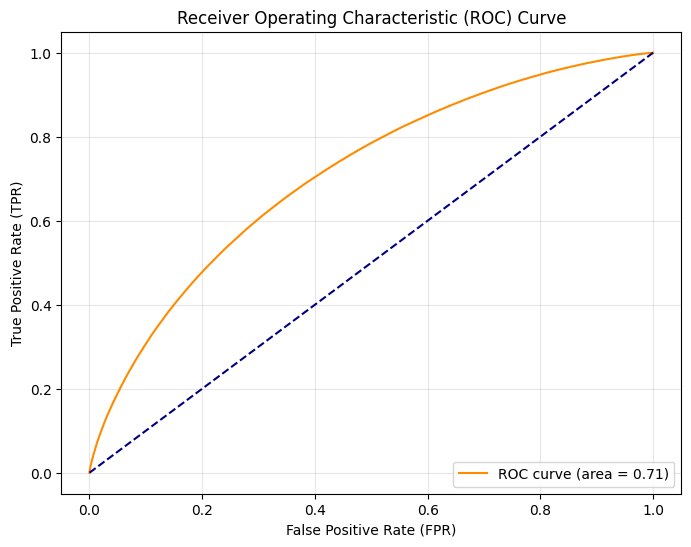

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. Calculate the AUC score
auc_value = roc_auc_score(y_test, y_pred_proba)

# 4. Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Diagonal random guess line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## PICK UP FOR PREDICTION

In [13]:
model = utils.unpickle_model('xgboostvFinal')

# Create a new flight example
# Note that it's a list, so can pass multiple flights or just one
new_flight = pd.DataFrame([{
    'OP_CARRIER': 'AS',
    'ORIGIN': 'PDX',
    'DEST': 'SFO',
    'CRS_DEP_TIME': 2055.0,
    'FL_DATE_MONTH': 3,
    'FL_DATE_DAY': 3
}])

cols = new_flight.select_dtypes(include=['object']).columns

obj_cols = new_flight.select_dtypes(include=['object']).columns
new_flight[obj_cols] = new_flight[obj_cols].astype('category')

prediction = model.predict(new_flight)
prediction

array([0])

## Catboost

In [14]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations = 100,
                               learning_rate=0.1,
                               max_depth = 5,
                                task_type="GPU",       # The "Magic" switch
                                devices='0', 
                               random_state=RANDOM_STATE)

# Fit the model with the training data
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
cat_model.fit(X_train, y_train, 
              cat_features=cat_cols,
              verbose=True)

# pickle_model(cat_model,'catboostv2')
# # model = unpickle_model('catboostv1')

0:	learn: 0.6592596	total: 184ms	remaining: 18.2s
1:	learn: 0.6317922	total: 257ms	remaining: 12.6s
2:	learn: 0.6090855	total: 337ms	remaining: 10.9s
3:	learn: 0.5903301	total: 421ms	remaining: 10.1s
4:	learn: 0.5739922	total: 506ms	remaining: 9.62s
5:	learn: 0.5603755	total: 587ms	remaining: 9.2s
6:	learn: 0.5489999	total: 662ms	remaining: 8.79s
7:	learn: 0.5394954	total: 783ms	remaining: 9s
8:	learn: 0.5314506	total: 872ms	remaining: 8.81s
9:	learn: 0.5247442	total: 953ms	remaining: 8.58s
10:	learn: 0.5191663	total: 1.04s	remaining: 8.38s
11:	learn: 0.5144570	total: 1.12s	remaining: 8.22s
12:	learn: 0.5104438	total: 1.22s	remaining: 8.16s
13:	learn: 0.5070903	total: 1.29s	remaining: 7.95s
14:	learn: 0.5042430	total: 1.37s	remaining: 7.77s
15:	learn: 0.5018553	total: 1.49s	remaining: 7.8s
16:	learn: 0.4998477	total: 1.58s	remaining: 7.74s
17:	learn: 0.4981650	total: 1.66s	remaining: 7.57s
18:	learn: 0.4967533	total: 1.79s	remaining: 7.64s
19:	learn: 0.4954504	total: 1.88s	remaining: 7

CatBoostClassifier(devices='0', iterations=100, learning_rate=0.1, max_depth=5, random_state=42, task_type='GPU')

In [15]:
# predict the target on the test dataset
y_predict = cat_model.predict(X_test)
print('Prediction on test data', y_predict) 

accuracy_test = metrics.accuracy_score(y_test, y_predict)
print('Accuracy_score on test dataset : ', accuracy_test)

y_pred_proba = cat_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print('ROC_AUC on test dataset : ', roc_auc)

f1 = f1_score(y_test, y_predict)
print(f'F1 Score on test dataset: {f1}')


Prediction on test data [False False False ... False False False]
Accuracy_score on test dataset :  0.7892726945682587
ROC_AUC on test dataset :  0.6817455478230712
F1 Score on test dataset: 0.04490741926396394


In [16]:
importances = cat_model.feature_importances_

feature_names = X_test.columns # Assuming X is your training DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 3. Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
3,CRS_DEP_TIME,35.808322
0,OP_CARRIER,24.628642
4,FL_DATE_MONTH,15.412168
2,DEST,9.446123
1,ORIGIN,8.945425
5,FL_DATE_DAY,5.759320


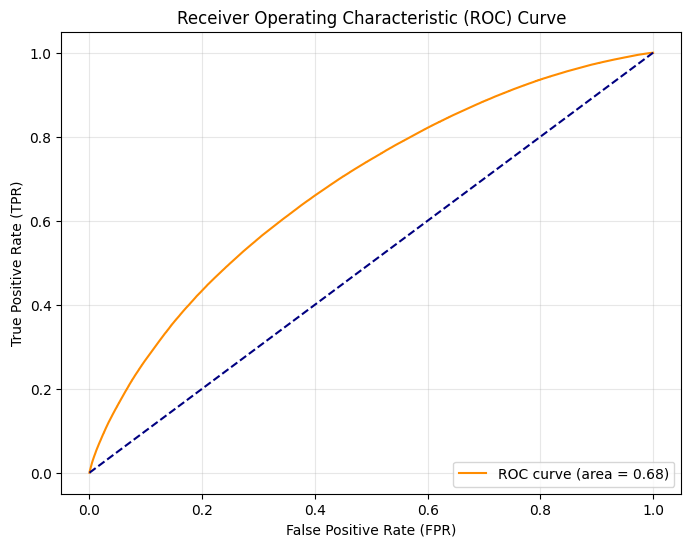

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. Calculate the AUC score
auc_value = roc_auc_score(y_test, y_pred_proba)

# 4. Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Diagonal random guess line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Random Forest

In [18]:
X_rf = X.copy()
y_class_rf = y_class.copy()

encoder = OrdinalEncoder()
all_airports = np.unique(X_rf[['ORIGIN', 'DEST']].values).reshape(-1, 1)

encoder = OrdinalEncoder()
encoder.fit(all_airports)

X_rf['ORIGIN'] = encoder.transform(X_rf[['ORIGIN']].values)
X_rf['DEST'] = encoder.transform(X_rf[['DEST']].values)

encoder = OrdinalEncoder()
X_rf['OP_CARRIER'] = encoder.fit_transform(X_rf[['OP_CARRIER']].values)


X_train, X_test, y_train, y_test = train_test_split(X_rf, y_class_rf, test_size=0.30, random_state=RANDOM_STATE)

In [19]:
# Instantiate the model object
rf_model = RandomForestClassifier(random_state=RANDOM_STATE, 
                                  n_estimators=100,
                                  max_depth=5,
                                  verbose = 1,
                                  n_jobs=-1)

# Fit the model with the training data
rf_model.fit(X_train, y_train)
print('Number of Trees used : ', model.n_estimators) # Find out number of trees used

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   19.5s


Number of Trees used :  500


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.5min finished


In [20]:
# utils.pickle_model(rf_model,'rfvFinal')
# model = unpickle_model('rfv2')

In [21]:
# Predict the target on the test dataset
y_predict = rf_model.predict(X_test)
print('\nPrediction on test data', y_predict) 

# Accuracy Score on test dataset
accuracy_test = metrics.accuracy_score(y_test, y_predict)
print('\nAccuracy_score on test dataset : ', accuracy_test)

f1 = f1_score(y_test, y_predict)
print(f'F1 Score on test dataset: {f1}')


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    1.2s finished



Prediction on test data [False False False ... False False False]

Accuracy_score on test dataset :  0.7878360523274923
F1 Score on test dataset: 0.0


In [22]:
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print('ROC_AUC on test dataset : ', roc_auc)


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    1.2s finished


ROC_AUC on test dataset :  0.6558543673631615


In [23]:
importances = rf_model.feature_importances_

feature_names = X_test.columns # Assuming X is your training DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 3. Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
3,CRS_DEP_TIME,0.765121
0,OP_CARRIER,0.141777
4,FL_DATE_MONTH,0.062463
5,FL_DATE_DAY,0.014544
2,DEST,0.008310
1,ORIGIN,0.007785


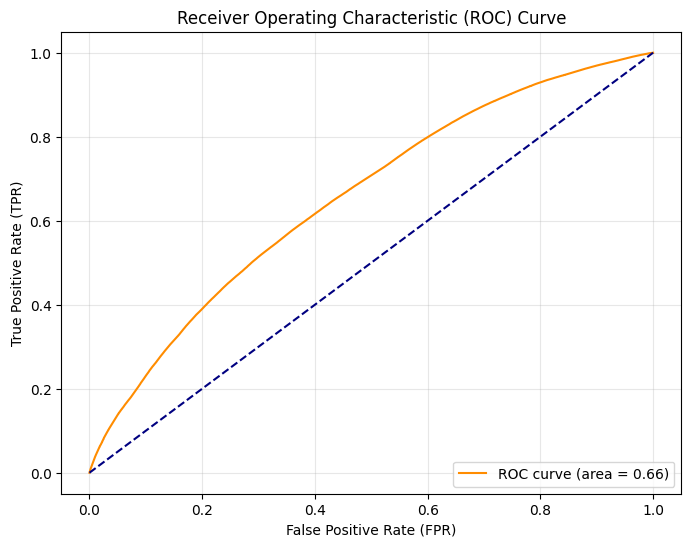

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. Calculate the AUC score
auc_value = roc_auc_score(y_test, y_pred_proba)

# 4. Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Diagonal random guess line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()